Import previous notebook to use its funcionts

In [1]:
import joblib as jl
import numpy as np 
import pandas as pd
#%run section_1_pre_processing.ipynb #if I must use functions defined in first notebook
print("Libraries imported successfully.")

df = jl.load('df.pkl')

# Load the label names using joblib (jl) instead of pandas to avoid errors
list_label_names = jl.load('df_fingerprint_list.pkl')


Libraries imported successfully.


# **Section 2 – Supervised learning – classification**

Classify the tactics of an attack session, based on the used words in the text and also possibly on time.

Each session can have multiple labels. y are labels

In [2]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

# loading
# Parse Set_Fingerprint (stored as string representation of list)
loaded_fingerprints = jl.load("df_fingerprint_list.pkl")
ed_fingerprints = jl.load("df_fingerprint_list.pkl")

# CHECK DI SICUREZZA: Conversione da stringa a lista se necessario
if isinstance(loaded_fingerprints[0], str):
    print("ATT Rilevated strings! Conversion into list")
    # Esempio: converte "['tag1', 'tag2']" -> ['tag1', 'tag2']
    loaded_fingerprints = [ast.literal_eval(x) for x in loaded_fingerprints]
    
print(f"1. Data loaded. Type: {type(loaded_fingerprints)}")
print(f"2. Number of samples (rows): {len(loaded_fingerprints)}")

# Sanity check on the first element to ensure it's a list/iterable
if len(loaded_fingerprints) > 0:
    print(f"3. First element sample (raw): {loaded_fingerprints[0]}")
    print(f"   Type of first element: {type(loaded_fingerprints[0])}") 
    # ^ Important: Should be <class 'list'> or <class 'set'>, NOT <class 'str'>


# Create the binary matrix for multi-label classification
multi_label_binarizer = MultiLabelBinarizer()
y = multi_label_binarizer.fit_transform(loaded_fingerprints)

#to check output
print(f"4. Number of unique classes found: {len(multi_label_binarizer.classes_)}")
print(f"5. 7 classes (labels): {multi_label_binarizer.classes_}")
print(f"6. Final 'y' matrix shape: {y.shape}") 
# y.shape should be (n_samples, n_classes)

# Dump
jl.dump(y, 'matrice_y.pkl')
print("'matrice_y.pkl' saved successfully \n")


1. Data loaded. Type: <class 'pandas.core.series.Series'>
2. Number of samples (rows): 233035
3. First element sample (raw): ['Defense Evasion' 'Discovery']
   Type of first element: <class 'numpy.ndarray'>
4. Number of unique classes found: 7
5. 7 classes (labels): ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']
6. Final 'y' matrix shape: (233035, 7)
'matrice_y.pkl' saved successfully 



### 2.1 Split data set

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# load tfidf matrix used into first notebook
X_tfidf = jl.load('X_tfidf_matrix.pkl')
# load y
y = jl.load('matrice_y.pkl')

# PRE-SPLIT DIMENSION CHECK
print(f"1. Shape of X (TF-IDF): {X_tfidf.shape}")
print(f"2. Shape of y (Target): {y.shape}")

# CRITICAL CHECK: The number of rows (samples) must match
if X_tfidf.shape[0] != y.shape[0]:
    print(f"!!! CRITICAL WARNING: Row count mismatch! X has {X_tfidf.shape[0]} but y has {y.shape[0]}")
    print("!!! The split will likely fail or produce incorrect results.")
else:
    print("OK: Row counts align.")

#SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,   # 20% of data for test set
    random_state=42
)

# POST-SPLIT DIMENSION CHECK
print(f"3. Train Set -> X: {X_train.shape}, y: {y_train.shape}")
print(f"4. Test Set  -> X: {X_test.shape}, y: {y_test.shape}")

# Verify split ratio
print(f"Actual Test percentage: {X_test.shape[0] / X_tfidf.shape[0]:.2%}")
print("Split completed successfully")

1. Shape of X (TF-IDF): (233035, 1000)
2. Shape of y (Target): (233035, 7)
OK: Row counts align.
3. Train Set -> X: (186428, 1000), y: (186428, 7)
4. Test Set  -> X: (46607, 1000), y: (46607, 7)
Actual Test percentage: 20.00%
Split completed successfully


Use the following function to print the confusin matrix of the two model

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_mcm(mcm, class_names, title="Model"):
    """
    Stampa la Multilabel Confusion Matrix usando lo stile 'bello' con ConfusionMatrixDisplay.
    
    Args:
        mcm: La matrice di confusione multilabel (output di multilabel_confusion_matrix)
        class_names: Lista con i nomi delle classi
        title: Titolo generale per i plot
    """
    n_classes = len(class_names)
    cols = min(3, n_classes)
    rows = (n_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    # Gestione caso singola classe o più classi per appiattire axes
    axes = axes.flatten() if n_classes > 1 else [axes]

    for i, class_label in enumerate(class_names):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=mcm[i],
            display_labels=[f'Not {class_label}', class_label]
        )
        # Lo stile che ti piaceva: Blues, valori interi, niente colorbar singola
        disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
        axes[i].set_title(f'Confusion Matrix: {class_label}', fontsize=10, fontweight='bold')

    # Nascondi assi vuoti se ci sono
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"{title} - Multilabel Confusion Matrices", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 2.2 Train 2 model

Initializes and trains a Random Forest Classifier, generating predictions and computing detailed performance metrics for both training and test sets. It displays the classification reports and visualizes the test set results using a custom confusion matrix plotting function.

CLASSIFICATION REPORT (TRAIN)
                 precision    recall  f1-score   support

Defense Evasion       0.99      0.98      0.99     15239
      Discovery       1.00      1.00      1.00    185712
      Execution       1.00      0.99      0.99     74415
       Harmless       0.92      0.19      0.31      1748
         Impact       1.00      1.00      1.00        25
          Other       1.00      0.98      0.99       260
    Persistence       1.00      1.00      1.00    169014

      micro avg       1.00      0.99      1.00    446413
      macro avg       0.99      0.88      0.90    446413
   weighted avg       1.00      0.99      1.00    446413
    samples avg       1.00      1.00      1.00    446413

------------------------------
CLASSIFICATION REPORT (TEST)
                 precision    recall  f1-score   support

Defense Evasion       1.00      0.97      0.98      3760
      Discovery       1.00      1.00      1.00     46433
      Execution       1.00      0.99      0.99     

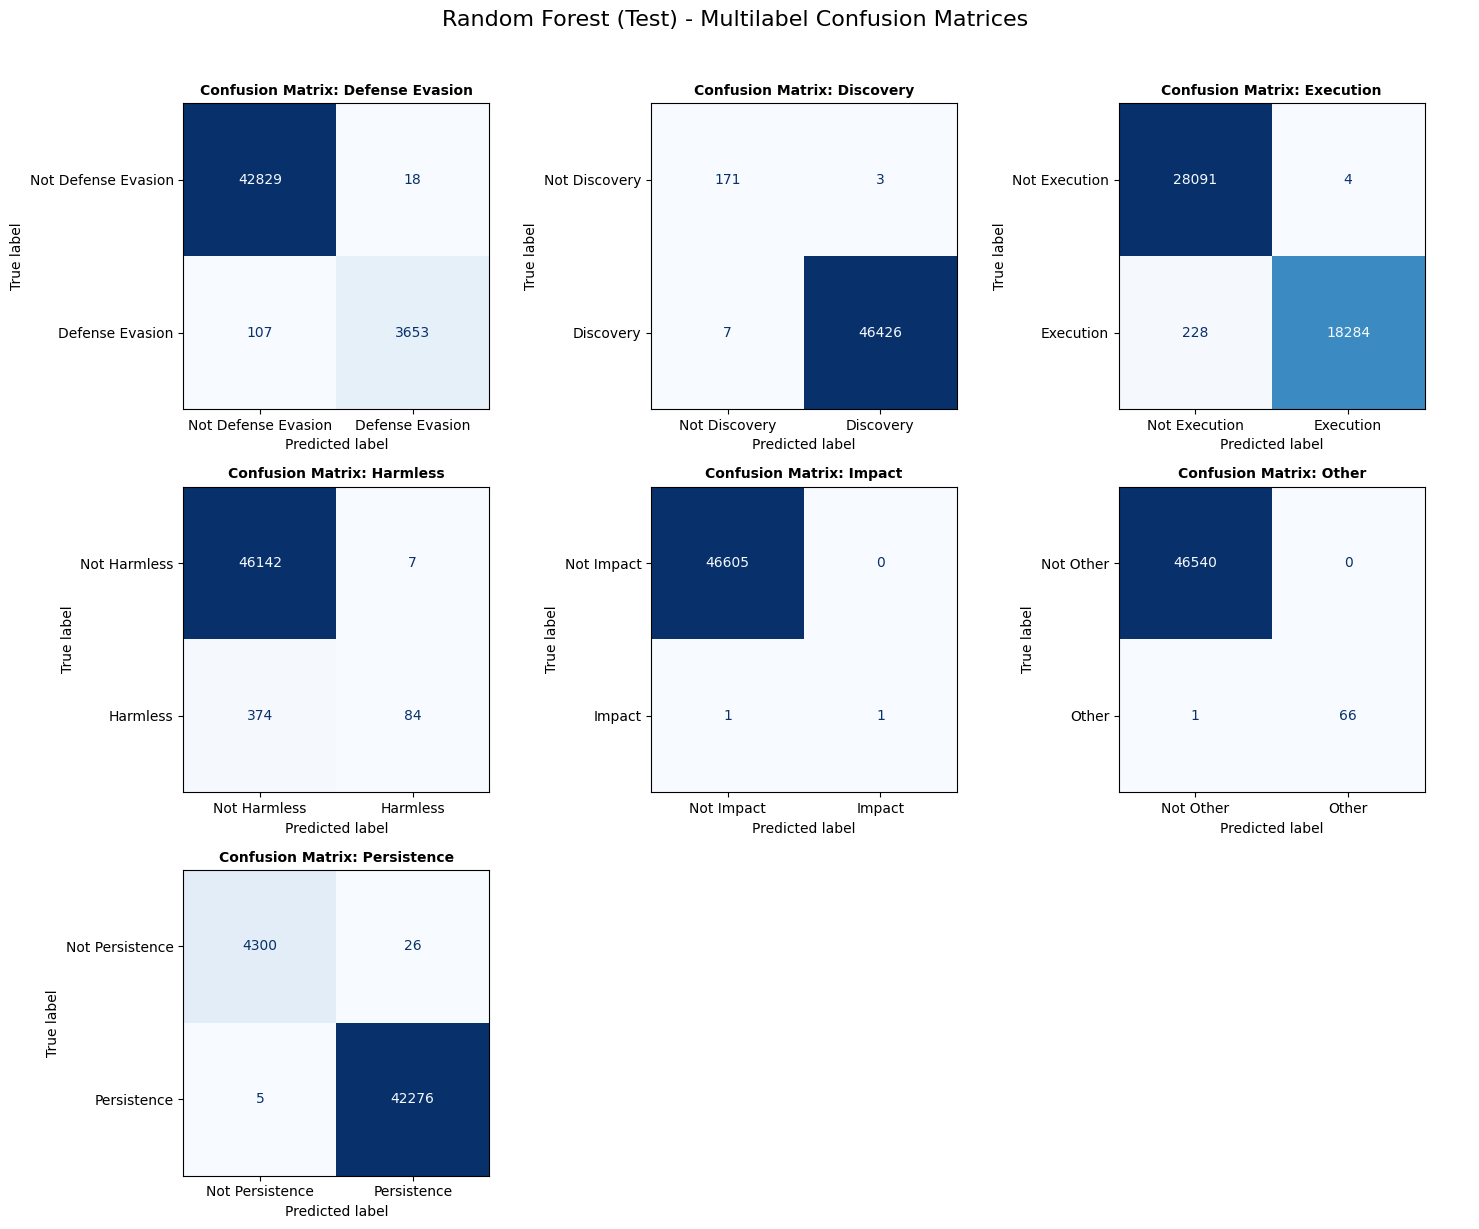

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# Model Creation and Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Compute Metrics
# Evaluation on TRAINING set
mcm_train_rf = multilabel_confusion_matrix(y_train, y_pred_train)
report_train_rf = classification_report(y_train, y_pred_train, target_names=multi_label_binarizer.classes_, zero_division=0)

# Evaluation on TEST set 
mcm_test_rf = multilabel_confusion_matrix(y_test, y_pred_test)
report_test_rf = classification_report(y_test, y_pred_test, target_names=multi_label_binarizer.classes_, zero_division=0)

# print
print("CLASSIFICATION REPORT (TRAIN)")
print(report_train_rf)
print("-" * 30)
print("CLASSIFICATION REPORT (TEST)")
print(report_test_rf)
print("-" * 30)

# Display confusion matrix
rf_class_names = multi_label_binarizer.classes_
plot_mcm(mcm_test_rf, rf_class_names, title="Random Forest (Test)")

Feature Importance: Random Forest


--- LEARNED RULES ANALYSIS (Feature Importance) ---
Vectorizer loaded from file.

Top 20 most decisive words for the model:
            word  importance
846           rm    0.030696
89          .ssh    0.027807
156            1    0.026790
422         bash    0.026192
54            -f    0.024359
116         /tmp    0.024235
43      --decode    0.022906
967           wc    0.022441
444           cd    0.019036
138     /var/tmp    0.018322
885        sleep    0.018084
133  /tmp/up.txt    0.018025
56            -i    0.017913
69            -s    0.017676
250         2>1&    0.017650
621           mv    0.017592
25           "1"    0.017428
616        mkdir    0.017256
58            -l    0.017005
261           4,    0.016638


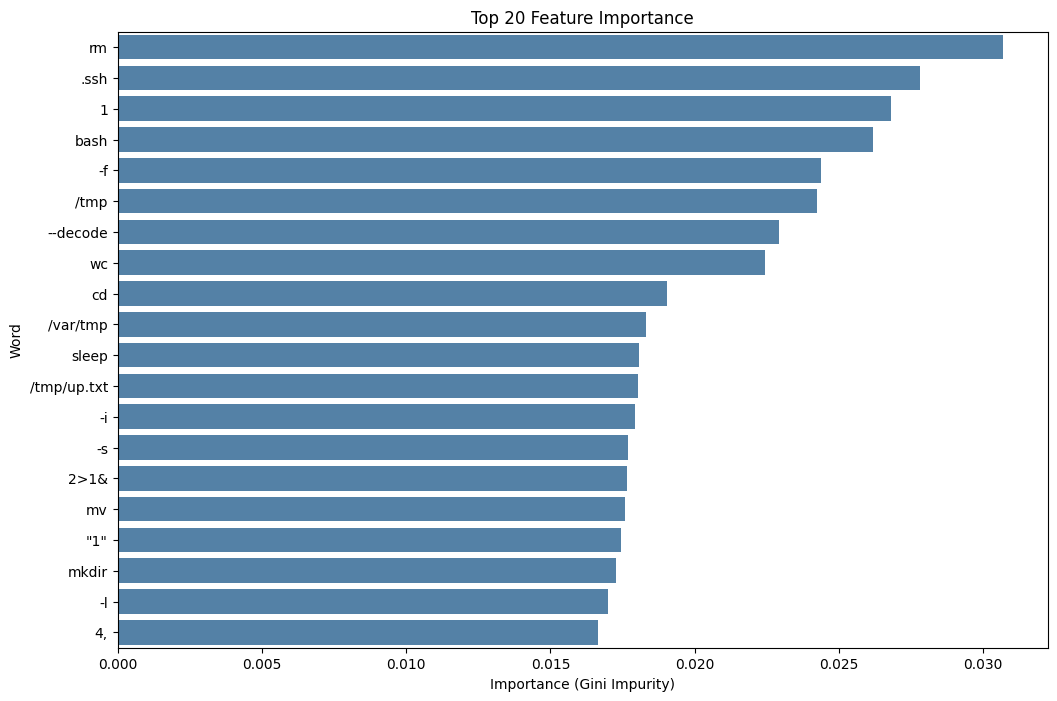

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib as jl

print("\n--- LEARNED RULES ANALYSIS (Feature Importance) ---")

try:
    # 1. Load the dictionary from Section 1 (if not already in memory)
    if 'tfidf_vectorizer' not in locals():
        try:
            tfidf_vectorizer = jl.load('tfidf_vectorizer.pkl')
            print("Vectorizer loaded from file.")
        except FileNotFoundError:
             print("WARNING: 'tfidf_vectorizer.pkl' not found. Make sure you saved it in Section 1.")
             raise

    # 2. Retrieve feature names (words)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # 3. Extract feature importance from Random Forest
    importances = rf_model.feature_importances_

    # 4. Create a DataFrame for the Top 20 words
    feature_imp_df = pd.DataFrame({
        'word': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).head(20)

    print("\nTop 20 most decisive words for the model:")
    print(feature_imp_df)

    # 5. Plot (Single color)
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='importance',
        y='word',
        data=feature_imp_df,
        color='steelblue'
    )
    plt.title('Top 20 Feature Importance')
    plt.xlabel('Importance (Gini Impurity)')
    plt.ylabel('Word')
    plt.show()
    
except Exception as e:
    print(f"Error during analysis: {e}")

Train a Multi-Output Logistic Regression model for multi-label classification, calculating performance metrics for both training and test sets. It then displays the classification reports and visualizes the confusion matrices for each specific class using a custom plotting function.

CLASSIFICATION REPORT (TRAIN)
                 precision    recall  f1-score   support

Defense Evasion       0.99      0.97      0.98     15239
      Discovery       1.00      1.00      1.00    185712
      Execution       1.00      0.99      0.99     74415
       Harmless       0.96      0.10      0.19      1748
         Impact       0.00      0.00      0.00        25
          Other       0.99      0.94      0.97       260
    Persistence       1.00      1.00      1.00    169014

      micro avg       1.00      0.99      1.00    446413
      macro avg       0.85      0.71      0.73    446413
   weighted avg       1.00      0.99      0.99    446413
    samples avg       1.00      0.99      1.00    446413

------------------------------
CLASSIFICATION REPORT (TEST)
                 precision    recall  f1-score   support

Defense Evasion       0.99      0.97      0.98      3760
      Discovery       1.00      1.00      1.00     46433
      Execution       1.00      0.99      0.99     

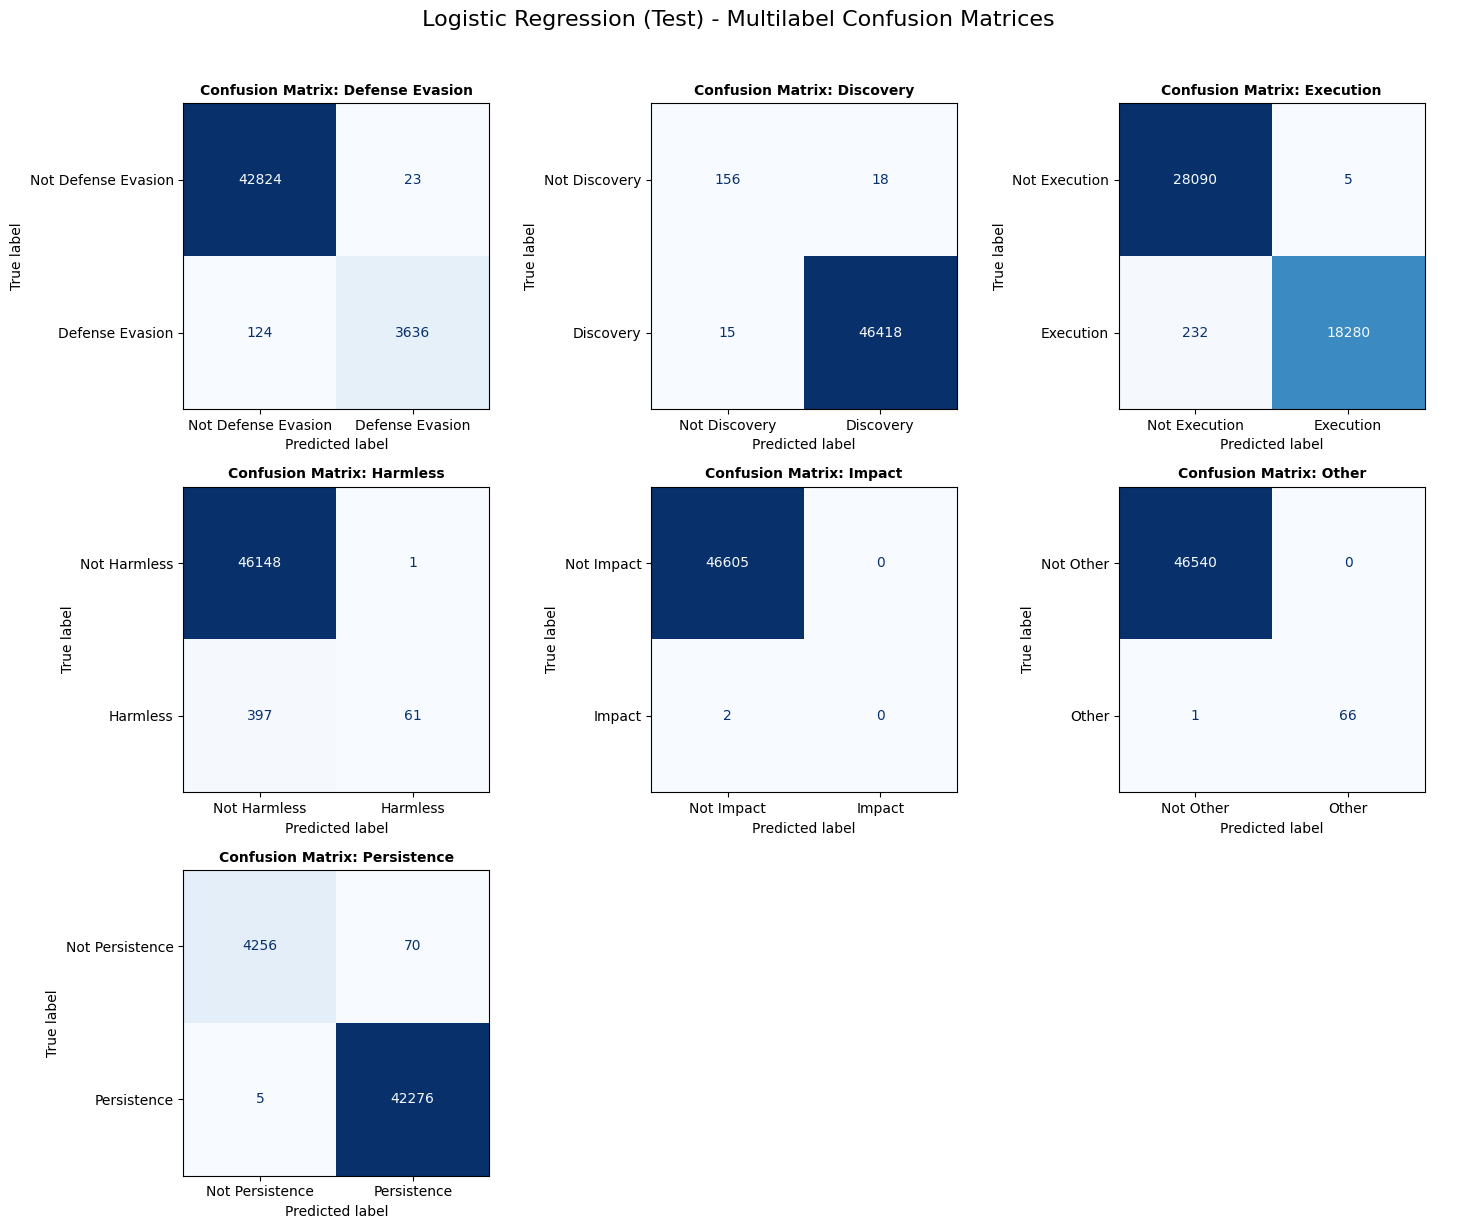

In [7]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# Use MultiOutputClassifier to handle multi-label
lr_model = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

# Evaluation on TRAINING set
mcm_lr_train = multilabel_confusion_matrix(y_train, y_pred_lr_train) 
report_lr_train = classification_report(y_train, y_pred_lr_train,target_names=multi_label_binarizer.classes_, zero_division=0)


# Evaluation on TEST set
mcm_lr_test = multilabel_confusion_matrix(y_test, y_pred_lr_test) 
report_lr_test = classification_report(y_test, y_pred_lr_test, target_names=multi_label_binarizer.classes_, zero_division=0)

#print report
print("CLASSIFICATION REPORT (TRAIN)")
print(report_lr_train)
print("-" * 30)
print("CLASSIFICATION REPORT (TEST)")
print(report_lr_test)
print("-" * 30)


# VISUALIZE confusion matrices for each class 
lr_class_names = multi_label_binarizer.classes_
plot_mcm(mcm_lr_test, lr_class_names, title=" Logistic Regression (Test)")

Feature importance: Logistic Regression

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib as jl
import numpy as np

print("\n--- LEARNED RULES ANALYSIS (Logistic Regression Coefficients) ---")

try:
    # 1. Load the dictionary from Section 1 (if not already in memory)
    if 'tfidf_vectorizer' not in locals():
        try:
            tfidf_vectorizer = jl.load('tfidf_vectorizer.pkl')
            print("Vectorizer loaded from file.")
        except FileNotFoundError:
             print("WARNING: 'tfidf_vectorizer.pkl' not found. Make sure you saved it in Section 1.")
             raise

    # 2. Retrieve feature names (words)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # 3. Extract Feature Importance from Logistic Regression
    # Since we use MultiOutputClassifier, we have a list of estimators (one per label)
    # We calculate the mean absolute coefficient across all estimators to find globally important words
    try:
        # Stack coefficients from all estimators: shape (n_classes, n_features)
        all_coefs = np.array([est.coef_.flatten() for est in lr_model.estimators_])
        # Calculate mean absolute importance
        importances = np.mean(np.abs(all_coefs), axis=0)
    except AttributeError:
        print("Error: Could not access coefficients. Make sure 'lr_model' is trained.")
        raise

    # 4. Create a DataFrame for the Top 20 words
    feature_imp_df = pd.DataFrame({
        'word': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).head(20)

    print("\nTop 20 most decisive words for the model (Mean Abs Coefficient):")
    print(feature_imp_df)

    # 5. Plot (Single color)
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='importance',
        y='word',
        data=feature_imp_df,
        color='indianred'
    )
    plt.title('Top 20 Words by Coefficient Magnitude (Logistic Regression)')
    plt.xlabel('Mean Absolute Coefficient')
    plt.ylabel('Word')
    plt.show()

except Exception as e:
    print(f"Error during analysis: {e}")


--- LEARNED RULES ANALYSIS (Logistic Regression Coefficients) ---

Top 20 most decisive words for the model (Mean Abs Coefficient):
                      word  importance
709                 passwd    6.262015
86                      .s    5.108478
484                   echo    4.210964
53                      -e    3.254366
580               lc_all=c    3.241505
867                    scp    3.188941
422                   bash    3.105943
97            /bin/busybox    2.922779
146                      0    2.908731
885                  sleep    1.998369
742                   perl    1.968525
272                      6    1.962126
542                      i    1.959231
450               chpasswd    1.944982
973                  which    1.784333
441                    cat    1.758517
142  /var/tmp/.var03522123    1.736628
28                  "admin    1.671421
64                      -p    1.671254
519                   grep    1.605271


Evaluate Random Forest and Logistic Regression models by analyzing F1-scores to detect overfitting or underfitting based on the generalization gap. It compares training and testing performance metrics for both classifiers and automatically identifies the best-performing model based on the test set results.

In [ ]:
print("\n" + "=" * 50)
print("OVERFITTING and UNDERFITTING ANALYSIS")
print("=" * 50)

# Extract F1-scores for comparison
def extract_f1(report_str):
    """Extract weighted avg f1-score from classification report string"""
    lines = report_str.split('\n')
    for line in lines:
        if 'weighted avg' in line:
            parts = line.split()
            return float(parts[-2])  # f1-score is second to last
    return 0.0

# Get f1-score from Random Forest and Logistic Regression
rf_train_f1 = extract_f1(report_train_rf)
rf_test_f1 = extract_f1(report_test_rf)
lr_train_f1 = extract_f1(report_lr_train)
lr_test_f1 = extract_f1(report_lr_test)

####################################
##### f1-score and check on rf #####
####################################
#print the f1 score of rf
print(f"\nRandom Forest:")
print(f"  Training F1: {rf_train_f1:.3f}")
print(f"  Test F1:     {rf_test_f1:.3f}")
print(f"  Gap:         {rf_train_f1 - rf_test_f1:.3f}")
#now do a check on over/under_fitting for rf
if rf_train_f1 - rf_test_f1 > 0.1:
    print("  OVERFITTING detected (large gap)")
elif rf_test_f1 < 0.6:
    print("   UNDERFITTING detected (low performance)")
else:
    print("  ✓ Good generalization")

####################################
##### f1-score and check on lr #####
####################################
#print the f1 score of lr
print(f"\nLogistic Regression:")
print(f"  Training F1: {lr_train_f1:.3f}")
print(f"  Test F1:     {lr_test_f1:.3f}")
print(f"  Gap:         {lr_train_f1 - lr_test_f1:.3f}")
#now do a check on over/under_fitting for lr
if lr_train_f1 - lr_test_f1 > 0.1:
    print("  OVERFITTING detected (large gap)")
elif lr_test_f1 < 0.6:
    print("  UNDERFITTING detected (low performance)")
else:
    print("  ✓ Good generalization")

#establish which model perform best
print("\n" + "=" * 50)
print("BEST MODEL")
print("=" * 50)
if rf_test_f1 > lr_test_f1:
    print(f" Random Forest performs best (Test F1: {rf_test_f1:.3f})")
else:
    print(f" Logistic Regression performs best (Test F1: {lr_test_f1:.3f})")




OVERFITTING and UNDERFITTING ANALYSIS

Random Forest:
  Training F1: 1.000
  Test F1:     1.000
  Gap:         0.000
  ✓ Good generalization

Logistic Regression:
  Training F1: 0.990
  Test F1:     0.990
  Gap:         0.000
  ✓ Good generalization

BEST MODEL
 Random Forest performs best (Test F1: 1.000)


### 2.3 Hyper-parameters tuning

Tunig for Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


print("\n" + "="*60)
print("3.A HYPER-PARAMETER TUNING - RANDOM FOREST")
print("="*60)

# --- 1. SUBSAMPLING FOR TUNING EFFICIENCY ---
# We use a subset (15k rows) to find the best parameters. This represents the distribution well but runs faster.
subset_size = 15000
print(f"1. Creating a subset of {subset_size} samples for fast tuning...")
X_tune = X_train[:subset_size]
y_tune = y_train[:subset_size]

# --- 2. DEFINE PARAMETER GRID ---
# We test if a simpler model (fewer trees) or constrained depth performs as well as the complex one.
# - n_estimators: 100 is default. Can 50 or 30 do the job? (Faster inference)
# - max_depth: Limiting depth prevents overfitting (though not an issue here) and reduces model size.
param_grid_rf = {
    'n_estimators': [30, 50, 100],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2]
}

# --- 3. SETUP GRID SEARCH ---
rf_base = RandomForestClassifier(random_state=42, n_jobs=1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,                    # 3-Fold Cross Validation is sufficient for this volume
    scoring='f1_weighted',   # Weighted F1 handles potential class imbalance better
    n_jobs=4,                # Limits CPU usage to 4 cores to prevent lag/crash
    verbose=1
)

# --- 4. EXECUTE TUNING (ON SUBSET) ---
print("2. Starting Grid Search on subset...")
grid_rf.fit(X_tune, y_tune)

print(f"\nBest Parameters found: {grid_rf.best_params_}")
print(f"Best Validation Score (F1): {grid_rf.best_score_:.4f}")

# --- 5. FINAL TRAINING (ON FULL DATASET) ---
# Now that we know the best parameters, we retrain a single model on the FULL training set.
print("\n3. Retraining the best model on the FULL training dataset...")
best_rf = grid_rf.best_estimator_
best_rf.n_jobs = -1
best_rf.fit(X_train, y_train)

# --- 6. FINAL EVALUATION ---
print("4. Evaluating optimized model on Test Set...")
y_pred_rf_opt = best_rf.predict(X_test)
print("-" * 60)
print(classification_report(y_test, y_pred_rf_opt, target_names=multi_label_binarizer.classes_, zero_division=0))
print("-" * 60)


3.A HYPER-PARAMETER TUNING - RANDOM FOREST
1. Creating a subset of 15000 samples for fast tuning...
2. Starting Grid Search on subset...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best Validation Score (F1): 0.9947

3. Retraining the best model on the FULL training dataset...
4. Evaluating optimized model on Test Set...
------------------------------------------------------------
                 precision    recall  f1-score   support

Defense Evasion       1.00      0.97      0.98      3760
      Discovery       1.00      1.00      1.00     46433
      Execution       1.00      0.99      0.99     18512
       Harmless       0.93      0.18      0.31       458
         Impact       1.00      0.50      0.67         2
          Other       1.00      0.99      0.99        67
    Persistence       1.00      1.00      1.00     42281

      micro avg       1.00      0.99      1.00    11

Tuning for Logistic Regression

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import numpy as np

print("\n" + "="*60)
print("3.B HYPER-PARAMETER TUNING - LOGISTIC REGRESSION")
print("="*60)

# --- 1. SUBSAMPLING ---
# We use a subset of 15,000 samples to speed up the grid search.
subset_size = 15000
print(f"1. Creating a subset of {subset_size} samples for tuning...")
X_tune = X_train[:subset_size]
y_tune_raw = y_train[:subset_size]

# --- 2. FILTERING CONSTANT CLASSES (CRITICAL STEP) ---
# In a small subset, rare classes (like 'Impact') might have only 0s.
# Logistic Regression crashes if a target column has only 1 class.
# We identify and keep only columns that have at least 2 classes (0 and 1).
non_constant_cols = [i for i in range(y_tune_raw.shape[1]) if len(np.unique(y_tune_raw[:, i])) > 1]

print(f"   Original classes: {y_tune_raw.shape[1]}")
print(f"   Active classes in subset: {len(non_constant_cols)}")

# Filter y_tune to include only valid columns for tuning
y_tune = y_tune_raw[:, non_constant_cols]

# --- 3. DEFINE PARAMETER GRID ---
# - estimator__C: Inverse of regularization strength (0.1 = Stronger regularization).
# - estimator__class_weight: 'balanced' automatically adjusts weights inversely proportionally to class frequencies.
param_grid_lr = {
    'estimator__C': [0.1, 1, 10],
    'estimator__class_weight': [None, 'balanced']
}

# --- 4. SETUP GRID SEARCH ---
base_lr = LogisticRegression(max_iter=1000, random_state=42)
multi_lr = MultiOutputClassifier(base_lr)

grid_lr = GridSearchCV(
    estimator=multi_lr,
    param_grid=param_grid_lr,
    cv=3,
    scoring='f1_weighted',
    n_jobs=4, # Keep CPU usage under control
    verbose=1
)

# --- 5. EXECUTE TUNING ---
print("2. Starting Grid Search on filtered subset...")
grid_lr.fit(X_tune, y_tune)

print(f"\nBest Parameters found: {grid_lr.best_params_}")
print(f"Best Validation Score (F1): {grid_lr.best_score_:.4f}")

# --- 6. FINAL RETRAINING (FULL DATASET) ---
# We extract the best parameters found.
best_C = grid_lr.best_params_['estimator__C']
best_weight = grid_lr.best_params_['estimator__class_weight']

print(f"\n3. Retraining final model with C={best_C} and class_weight={best_weight} on FULL dataset...")

# Create a fresh model with the best parameters found
final_lr = MultiOutputClassifier(
    LogisticRegression(C=best_C, class_weight=best_weight, max_iter=1000, random_state=42, n_jobs=-1)
)
final_lr.fit(X_train, y_train)

# --- 7. FINAL EVALUATION ---
print("4. Evaluating optimized model on Test Set...")
y_pred_lr_opt = final_lr.predict(X_test)
print("-" * 60)
print(classification_report(y_test, y_pred_lr_opt, target_names=multi_label_binarizer.classes_, zero_division=0))
print("-" * 60)


3.B HYPER-PARAMETER TUNING - LOGISTIC REGRESSION
1. Creating a subset of 15000 samples for tuning...
   Original classes: 7
   Active classes in subset: 6
2. Starting Grid Search on filtered subset...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters found: {'estimator__C': 10, 'estimator__class_weight': None}
Best Validation Score (F1): 0.9939

3. Retraining final model with C=10 and class_weight=None on FULL dataset...
4. Evaluating optimized model on Test Set...
------------------------------------------------------------
                 precision    recall  f1-score   support

Defense Evasion       0.99      0.97      0.98      3760
      Discovery       1.00      1.00      1.00     46433
      Execution       1.00      0.99      0.99     18512
       Harmless       0.93      0.18      0.31       458
         Impact       0.00      0.00      0.00         2
          Other       1.00      0.99      0.99        67
    Persistence       1.00      1.00     

### 2.5: Combining Features

Features for Random Forest

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score


print("\n" + "="*60)
print("2.5 FEATURE EXPLORATION & ABLATION STUDY - RANDOM FOREST")
print("="*60)

# --- 0. BASELINE TF-IDF CALCULATION ---
# We calculate the score using the predictions from the Tuning step (y_pred_rf_opt)
# This ensures the number is real and not hardcoded.
try:
    f1_tfidf_rf = f1_score(y_test, y_pred_rf_opt, average='micro')
    print(f"1. TF-IDF Baseline Score (calculated): {f1_tfidf_rf:.4f}")
except NameError:
    print("Error: 'y_pred_rf_opt' not found. Run the Tuning step (3.A) first.")
    f1_tfidf_rf = 0.0

# --- 1. PREPARE DATA FOR EXPERIMENTS ---
if 'cleaned_sessions' not in locals():
    print("Regenerating cleaned_sessions...")
    def clean_token(text):
        text = str(text).replace('$', '').replace("'{ }", '').replace('{', '').replace('}', '')
        return text
    cleaned_sessions = df['full_session'].apply(clean_token)

if 'n_chars' not in df.columns:
    df['n_chars'] = df['full_session'].astype(str).apply(len)
    df['n_words'] = df['full_session'].astype(str).str.split().apply(len)

# --- 2. EXPERIMENT A: Bag of Words (BoW) ---
print("\n2. Training Random Forest with Bag of Words...")

# Create BoW Matrix
bow_vectorizer = CountVectorizer(token_pattern=r'\S+', max_features=1000)
X_bow = bow_vectorizer.fit_transform(cleaned_sessions)

# Split (same random_state as TF-IDF for fair comparison)
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, y, test_size=0.2, random_state=42)

# Train RF (Light configuration: 50 trees)
rf_bow = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_bow.fit(X_train_bow, y_train_bow)
y_pred_bow = rf_bow.predict(X_test_bow)

f1_bow_rf = f1_score(y_test_bow, y_pred_bow, average='micro')
print(f"F1-Score (BoW): {f1_bow_rf:.4f}")


# --- 3. EXPERIMENT B: Metadata Only ---
print("\n3. Training Random Forest with Metadata Only (n_chars, n_words)...")

X_meta = df[['n_chars', 'n_words']].values
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(X_meta, y, test_size=0.2, random_state=42)

rf_meta = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_meta.fit(X_train_meta, y_train_meta)
y_pred_meta = rf_meta.predict(X_test_meta)

f1_meta_rf = f1_score(y_test_meta, y_pred_meta, average='micro')
print(f"F1-Score (Metadata): {f1_meta_rf:.4f}")

# --- 4. COMPARISON SUMMARY ---
print("\n" + "="*60)
print("COMPARATIVE RESULTS - RANDOM FOREST (F1-Score Micro)")
print("-" * 60)
print(f"1. TF-IDF (Baseline):   {f1_tfidf_rf:.4f}")
print(f"2. Bag of Words:        {f1_bow_rf:.4f}")
print(f"3. Metadata Only:       {f1_meta_rf:.4f}")
print("=" * 60)


2.5 FEATURE EXPLORATION & ABLATION STUDY - RANDOM FOREST
1. TF-IDF Baseline Score (calculated): 0.9965

2. Training Random Forest with Bag of Words...
F1-Score (BoW): 0.9965

3. Training Random Forest with Metadata Only (n_chars, n_words)...
F1-Score (Metadata): 0.9961

COMPARATIVE RESULTS - RANDOM FOREST (F1-Score Micro)
------------------------------------------------------------
1. TF-IDF (Baseline):   0.9965
2. Bag of Words:        0.9965
3. Metadata Only:       0.9961


Features for Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

print("\n" + "="*60)
print("2.5 FEATURE EXPLORATION & ABLATION STUDY - LOGISTIC REGRESSION")
print("="*60)

# --- 0. BASELINE TF-IDF CALCULATION ---
try:
    f1_tfidf_lr = f1_score(y_test, y_pred_lr_opt, average='micro')
    print(f"1. TF-IDF Baseline Score (calculated): {f1_tfidf_lr:.4f}")
except NameError:
    print("Error: 'y_pred_lr_opt' not found. Run the Tuning step (3.B) first.")
    f1_tfidf_lr = 0.0

# --- 1. EXPERIMENT A: Bag of Words (BoW) ---
print("\n2. Training Logistic Regression with Bag of Words...")
# Reuse X_train_bow from previous block to save time/memory
# Note: MultiOutputClassifier is needed for multi-label LR
lr_bow = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
lr_bow.fit(X_train_bow, y_train_bow)
y_pred_bow_lr = lr_bow.predict(X_test_bow)

f1_bow_lr = f1_score(y_test_bow, y_pred_bow_lr, average='micro')
print(f"F1-Score (BoW): {f1_bow_lr:.4f}")

# --- 2. EXPERIMENT B: Metadata Only ---
print("\n3. Training Logistic Regression with Metadata Only...")
# Reuse X_train_meta from previous block
lr_meta = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr_meta.fit(X_train_meta, y_train_meta)
y_pred_meta_lr = lr_meta.predict(X_test_meta)

f1_meta_lr = f1_score(y_test_meta, y_pred_meta_lr, average='micro')
print(f"F1-Score (Metadata): {f1_meta_lr:.4f}")

# --- 3. COMPARISON SUMMARY ---
print("\n" + "="*60)
print("COMPARATIVE RESULTS - LOGISTIC REGRESSION (F1-Score Micro)")
print("-" * 60)
print(f"1. TF-IDF (Baseline):   {f1_tfidf_lr:.4f}")
print(f"2. Bag of Words:        {f1_bow_lr:.4f}")
print(f"3. Metadata Only:       {f1_meta_lr:.4f}")
print("=" * 60)


2.5 FEATURE EXPLORATION & ABLATION STUDY - LOGISTIC REGRESSION
1. TF-IDF Baseline Score (calculated): 0.9960

2. Training Logistic Regression with Bag of Words...
F1-Score (BoW): 0.9964

3. Training Logistic Regression with Metadata Only...
F1-Score (Metadata): 0.9894

COMPARATIVE RESULTS - LOGISTIC REGRESSION (F1-Score Micro)
------------------------------------------------------------
1. TF-IDF (Baseline):   0.9960
2. Bag of Words:        0.9964
3. Metadata Only:       0.9894
